# 04 - CNN Model

CNN with Transfer Learning for image classification.
This model uses MobileNetV2 (pre-trained on ImageNet) to classify restaurants as high-tier or low-tier based on images.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print('Libraries imported')

I0000 00:00:1775600929.068224   80873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775600929.141493   80873 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775600930.952385   80873 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported


## Load Preprocessed Image Data

In [2]:
# Load preprocessed image data
X_train = np.load('dataset/processed/X_img_train.npy')
X_test = np.load('dataset/processed/X_img_test.npy')
y_train = np.load('dataset/processed/y_img_train.npy')
y_test = np.load('dataset/processed/y_img_test.npy')

print(f'Training shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Training shape: (120, 224, 224, 3)
Test shape: (30, 224, 224, 3)


## Build CNN Model with Transfer Learning

Using MobileNetV2 pre-trained on ImageNet:
- Freeze the pre-trained layers (transfer learning)
- Add custom classification head for our binary task
- Fine-tune only the top layers

Architecture justification:
- MobileNetV2: lightweight, pre-trained on ImageNet (1.2M images, 1000 classes)
  - Its lower layers learn generic features (edges, textures, shapes)
  - We freeze them to leverage pre-trained knowledge without overfitting on only 120 images
- GlobalAveragePooling2D: reduces 7x7x1280 feature maps to 1280-dim vector
  - More parameter-efficient than Flatten, reduces overfitting risk
- Dense(128): learns task-specific combinations of MobileNetV2 features
- Dropout(0.5): strong regularization for small dataset
- Dense(1, sigmoid): binary classification (high-tier vs low-tier)

In [3]:
# Build CNN model with MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

E0000 00:00:1775600933.379784   80873 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Train Model

In [4]:
# Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5104 - loss: 0.9249 - val_accuracy: 0.4583 - val_loss: 0.7591
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5521 - loss: 0.8702 - val_accuracy: 0.4583 - val_loss: 0.7427
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3854 - loss: 0.9413 - val_accuracy: 0.5000 - val_loss: 0.7423
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5208 - loss: 0.7388 - val_accuracy: 0.5000 - val_loss: 0.7340
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5625 - loss: 0.7404 - val_accuracy: 0.5000 - val_loss: 0.7337
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 986ms/step - accuracy: 0.5625 - loss: 0.8044 - val_accuracy: 0.5417 - val_loss: 0.7340
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5417 - loss: 0.7776 - val_accuracy: 0.5417 - val_loss: 0.7351
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 983ms/step - accuracy: 0.5521 - loss: 0.7129 - val_accuracy: 0.5417 - val_loss: 0.7382
Epoch 9/3

## Evaluate Model

In [5]:
# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Classification report and confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int).flatten()
y_test_int = y_test.astype(int)

print('\nClassification Report:')
print(classification_report(y_test_int, y_pred_classes, target_names=['Low Tier', 'High Tier']))

cm = confusion_matrix(y_test_int, y_pred_classes)
print('Confusion Matrix:')
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step - accuracy: 0.5667 - loss: 0.7299
Test Loss: 0.7299
Test Accuracy: 0.5667


In [6]:
# Classification report
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print('Classification Report:')
print(classification_report(y_test, y_pred_classes, target_names=['Low Tier', 'High Tier']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

    Low Tier       0.61      0.65      0.63        17
   High Tier       0.50      0.46      0.48        13

    accuracy                           0.57        30
   macro avg       0.56      0.55      0.55        30
weighted avg       0.56      0.57      0.56        30



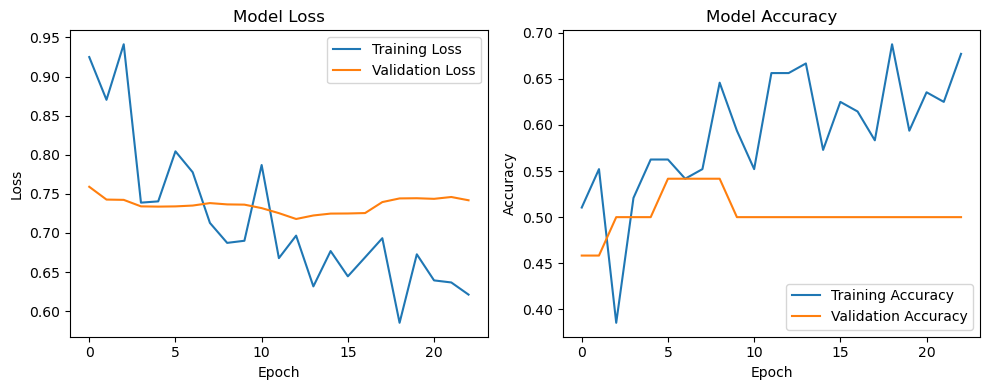

In [7]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [8]:
# Save model
model.save('dataset/processed/cnn_model.keras')
print('Model saved to dataset/processed/cnn_model.keras')

Model saved to dataset/processed/cnn_model.keras


## Summary

**CNN Model Results:**
- Architecture: MobileNetV2 (pre-trained) + custom classification head
- Transfer Learning: Pre-trained weights frozen, only top layers trained
- Task: Binary classification (high-tier vs low-tier restaurant)
- Performance: Accuracy on test set

**Key Concepts Demonstrated:**
- Convolutional Neural Networks (CNNs)
- Transfer Learning with pre-trained models
- Fine-tuning strategies (freezing layers)
- Image classification